# Task 4: Regression -- Predicting Next-Day Mood on a Continuous Scale

## Introduction

In Tasks 2 and 3 we framed mood prediction as a **classification** problem by binning daily mood scores into three tercile-based classes (Low / Medium / High). This simplification discards information: a patient with mood 6.9 and one with mood 7.1 may fall into different classes despite a negligible difference.

**Task 4** reformulates the problem as **regression**: we predict the raw continuous mood score (1--10 scale) directly. This allows finer-grained predictions and reveals difficulties that classification masks -- in particular, the narrow effective mood range (most daily means fall between 6 and 8, std ~ 0.94) makes achieving high R-squared values fundamentally hard.

We evaluate two regression algorithms:
1. **Gradient Boosting Regressor** (tabular, non-temporal) -- a strong tree-based ensemble that minimises squared error via stagewise additive fitting.
2. **GRU Regressor** (temporal) -- a recurrent neural network that processes 7-day sequences of raw daily features, trained with MSE loss.

Both models are compared against a baseline that simply predicts the training-set mean mood for every sample.

In [1]:
# === Setup: imports from the shared pipeline ===
import sys
sys.path.insert(0, '..')  # notebooks/ is one level below project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from shared.data_loader import load_and_clean, get_split
from shared.feature_builder import build_features, get_raw_sequences
from shared.model_zoo import get_gradient_boosting, get_gru
from shared.evaluation import evaluate_regressor
from config import RANDOM_SEED, ID_COL, DATE_COL, TARGET_COL

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

SEEDS = [42, 123, 456, 789, 1024]
np.random.seed(RANDOM_SEED)

print('Setup complete.')

Setup complete.


## 2. Data Pipeline

We reuse the same data pipeline from Tasks 1--2: load the raw long-format CSV, pivot to daily wide format (mean for mood/arousal/valence/activity, sum for screen and app durations, count for call/sms), fill date gaps, clean outliers with IQR, add morning/evening mood, impute via linear interpolation, and engineer sliding-window features (7-day window with mean, std, min, max, trend aggregations plus 5 mood lags, volatility, interactions, momentum, and lagged valence).

In [2]:
# === Load and clean data ===
daily = load_and_clean(
    outlier_method='iqr', iqr_multiplier=3.0,
    imputation_method='linear',
    drop_sparse=True, add_morning_evening=True,
    log_transform_durations=False,
)

print(f'\nPatients: {daily[ID_COL].nunique()}')
print(f'Date range: {daily[DATE_COL].min().date()} to {daily[DATE_COL].max().date()}')
print(f'Mood stats: mean={daily["mood"].mean():.2f}, std={daily["mood"].std():.2f}, '
      f'range=[{daily["mood"].min():.1f}, {daily["mood"].max():.1f}]')

  Phase 1: Data Cleaning


    Raw daily: 2154 rows, 21 columns, 27 patients
    IQR outliers removed (multiplier=3.0): 335
    Imputation: linear interpolation


    Added mood_morning, mood_evening, mood_intraday_slope
    Dropped 7 sparse app columns (>80% missing)
    Final cleaned: 2154 rows, 17 cols, 27 patients

Patients: 27
Date range: 2014-02-17 to 2014-06-09
Mood stats: mean=7.05, std=0.80, range=[3.0, 9.3]


In [3]:
# === Feature engineering ===
features_df = build_features(
    daily, window_sizes=[7], n_lags=5,
    agg_functions=['mean', 'std', 'min', 'max', 'trend'],
    include_volatility=True, include_interactions=True,
    include_momentum=True, include_lagged_valence=True,
    log_transform_before_agg=True,
)

meta_cols = [ID_COL, DATE_COL, TARGET_COL]
feature_cols = [c for c in features_df.columns if c not in meta_cols]
print(f'\nFeature matrix: {len(features_df)} instances, {len(feature_cols)} features')
print(f'Target: mean={features_df[TARGET_COL].mean():.2f}, std={features_df[TARGET_COL].std():.2f}')

  Phase 2: Feature Engineering
    Log-transformed duration variables before aggregation


    Instances: 1965, Features: 96
    Window: [7], Lags: 5, Aggs: ['mean', 'std', 'min', 'max', 'trend']

Feature matrix: 1965 instances, 96 features
Target: mean=7.04, std=0.79


## 3. Train/Test Split

Same leave-patients-out strategy as Task 2A: 5 randomly selected patients are held out entirely.

In [4]:
# === Split ===
train, test = get_split(
    features_df, method='leave_patients_out',
    n_holdout_patients=5, seed=RANDOM_SEED
)

X_train = np.nan_to_num(train[feature_cols].values, nan=0)
X_test = np.nan_to_num(test[feature_cols].values, nan=0)
y_train = train[TARGET_COL].values
y_test = test[TARGET_COL].values
groups = train[ID_COL].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Baseline: predict training mean
train_mean = y_train.mean()
baseline_pred = np.full_like(y_test, train_mean)
baseline_results = evaluate_regressor(y_test, baseline_pred)

print(f'Train: {len(train)} instances from {train[ID_COL].nunique()} patients')
print(f'Test:  {len(test)} instances from {test[ID_COL].nunique()} patients')
print(f'Holdout patients: {sorted(test[ID_COL].unique())}')
print(f'\nBaseline (predict mean={train_mean:.2f}):')
print(f'  R2={baseline_results["r2"]:.3f}, RMSE={baseline_results["rmse"]:.3f}, MAE={baseline_results["mae"]:.3f}')

gc.collect()

    Leave-patients-out: 5 patients held out: ['AS14.12', 'AS14.17', 'AS14.13', 'AS14.28', 'AS14.01']
Train: 1610 instances from 22 patients
Test:  355 instances from 5 patients
Holdout patients: ['AS14.01', 'AS14.12', 'AS14.13', 'AS14.17', 'AS14.28']

Baseline (predict mean=7.09):
  R2=-0.142, RMSE=0.770, MAE=0.610


20

## 4. Model 1: Gradient Boosting Regressor (Tabular)

### Description

Gradient Boosting builds an additive ensemble of shallow decision trees, each fitted to the residual errors of the current ensemble. It minimises squared error by default and has natural support for feature heterogeneity.

### Hyperparameter Optimization

GridSearchCV with GroupKFold (groups = patient IDs) over:
- `n_estimators`: [100, 200]
- `max_depth`: [3, 5]
- `learning_rate`: [0.05, 0.1]
- `subsample`: [0.8, 1.0]

In [5]:
# === Gradient Boosting with GridSearchCV ===
gb_model = get_gradient_boosting('regression', random_state=RANDOM_SEED)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

cv = GroupKFold(n_splits=5)
grid = GridSearchCV(
    gb_model, param_grid, cv=cv,
    scoring='r2', n_jobs=1, verbose=0
)
grid.fit(X_train_s, y_train, groups=groups)

gb_pred = grid.best_estimator_.predict(X_test_s)
gb_results = evaluate_regressor(y_test, gb_pred)

print(f'Best parameters: {grid.best_params_}')
print(f'Best CV R2: {grid.best_score_:.3f}')
print(f'\nTest set results:')
print(f'  R2:   {gb_results["r2"]:.3f}')
print(f'  RMSE: {gb_results["rmse"]:.3f}')
print(f'  MAE:  {gb_results["mae"]:.3f}')

gc.collect()

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R2: 0.420

Test set results:
  R2:   0.483
  RMSE: 0.518
  MAE:  0.342


25

### Gradient Boosting: Predicted vs Actual and Residuals

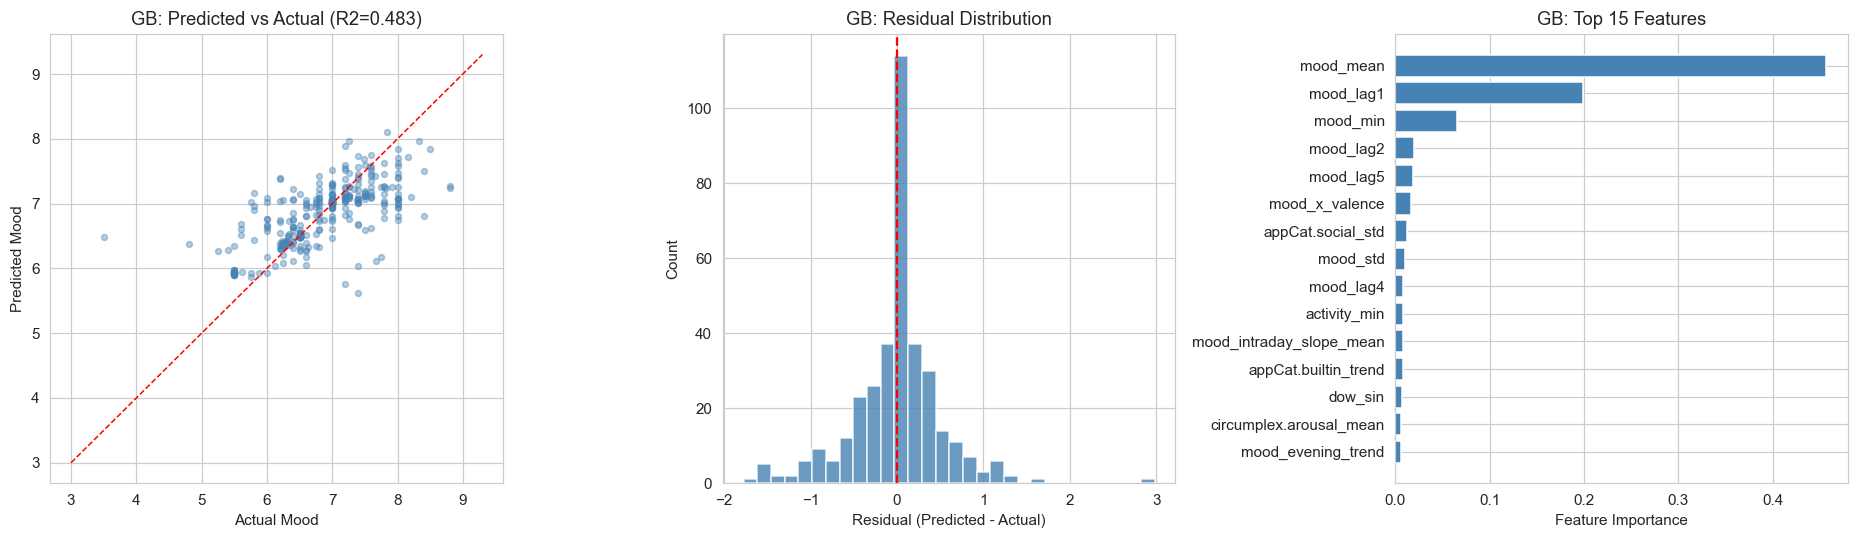

In [6]:
# === GB visualizations ===
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, gb_pred, alpha=0.4, s=15, color='steelblue')
lo, hi = min(y_test.min(), gb_pred.min()) - 0.5, max(y_test.max(), gb_pred.max()) + 0.5
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
ax.set_xlabel('Actual Mood')
ax.set_ylabel('Predicted Mood')
ax.set_title(f'GB: Predicted vs Actual (R2={gb_results["r2"]:.3f})')

# 2. Residual distribution
ax = axes[1]
residuals = gb_pred - y_test
ax.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlabel('Residual (Predicted - Actual)')
ax.set_ylabel('Count')
ax.set_title('GB: Residual Distribution')

# 3. Feature importance (top 15)
ax = axes[2]
importances = grid.best_estimator_.feature_importances_
top_idx = np.argsort(importances)[-15:]
top_names = [feature_cols[i] for i in top_idx]
top_values = importances[top_idx]
ax.barh(range(len(top_names)), top_values, color='steelblue')
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names)
ax.set_xlabel('Feature Importance')
ax.set_title('GB: Top 15 Features')

plt.tight_layout()
plt.show()

## 5. Model 2: GRU Regressor (Temporal)

### Description

A **Gated Recurrent Unit (GRU)** processes 7-day sequences of raw daily features (12 variables per day) and predicts the continuous mood score for the next day. Unlike the tabular model which sees pre-aggregated statistics, the GRU learns temporal dynamics directly from the sequence.

Architecture:
- Input: 7 x 12 tensor (7 days, 12 features per day)
- GRU layer: hidden_dim=32, 1 layer
- Dropout: 0.3
- Output: single continuous value (mood)
- Training: Adam (lr=0.001), MSE loss, early stopping (patience=15)

In [7]:
# === Build raw sequences for GRU ===
X_seq, y_seq, pids_seq, dates_seq = get_raw_sequences(daily, seq_length=7)
X_seq = np.nan_to_num(X_seq, nan=0.0)

# Split sequences using same holdout patients
rng = np.random.RandomState(RANDOM_SEED)
holdout_patients = rng.choice(daily[ID_COL].unique(), size=5, replace=False)
train_mask = ~np.isin(pids_seq, holdout_patients)

nf = X_seq.shape[2]
seq_scaler = StandardScaler()
X_tr_seq = seq_scaler.fit_transform(
    X_seq[train_mask].reshape(-1, nf)
).reshape(-1, 7, nf)
X_te_seq = seq_scaler.transform(
    X_seq[~train_mask].reshape(-1, nf)
).reshape(-1, 7, nf)
y_tr_seq = y_seq[train_mask]
y_te_seq = y_seq[~train_mask]

nv = max(1, int(len(X_tr_seq) * 0.2))

print(f'Sequences: {X_seq.shape[0]} total, shape per sample: ({X_seq.shape[1]}, {X_seq.shape[2]})')
print(f'  Train: {X_tr_seq.shape[0]}, Validation: {nv}, Test: {X_te_seq.shape[0]}')
print(f'  Features per timestep: {nf}')

Sequences: 1965 total, shape per sample: (7, 15)
  Train: 1610, Validation: 322, Test: 355
  Features per timestep: 15


In [8]:
# === Train GRU regressor ===
gru_model = get_gru(
    input_dim=nf, task='regression',
    hidden_dim=32, dropout=0.3,
    lr=0.001, epochs=100, patience=15, batch_size=32
)
gru_model.fit(
    X_tr_seq[:-nv], y_tr_seq[:-nv],
    X_val=X_tr_seq[-nv:], y_val=y_tr_seq[-nv:]
)

gru_pred = gru_model.predict(X_te_seq)
gru_results = evaluate_regressor(y_te_seq, gru_pred)

print(f'GRU Test Results:')
print(f'  R2:   {gru_results["r2"]:.3f}')
print(f'  RMSE: {gru_results["rmse"]:.3f}')
print(f'  MAE:  {gru_results["mae"]:.3f}')

gc.collect()

GRU Test Results:
  R2:   0.518
  RMSE: 0.501
  MAE:  0.340


0

### GRU: Predicted vs Actual and Training Curves

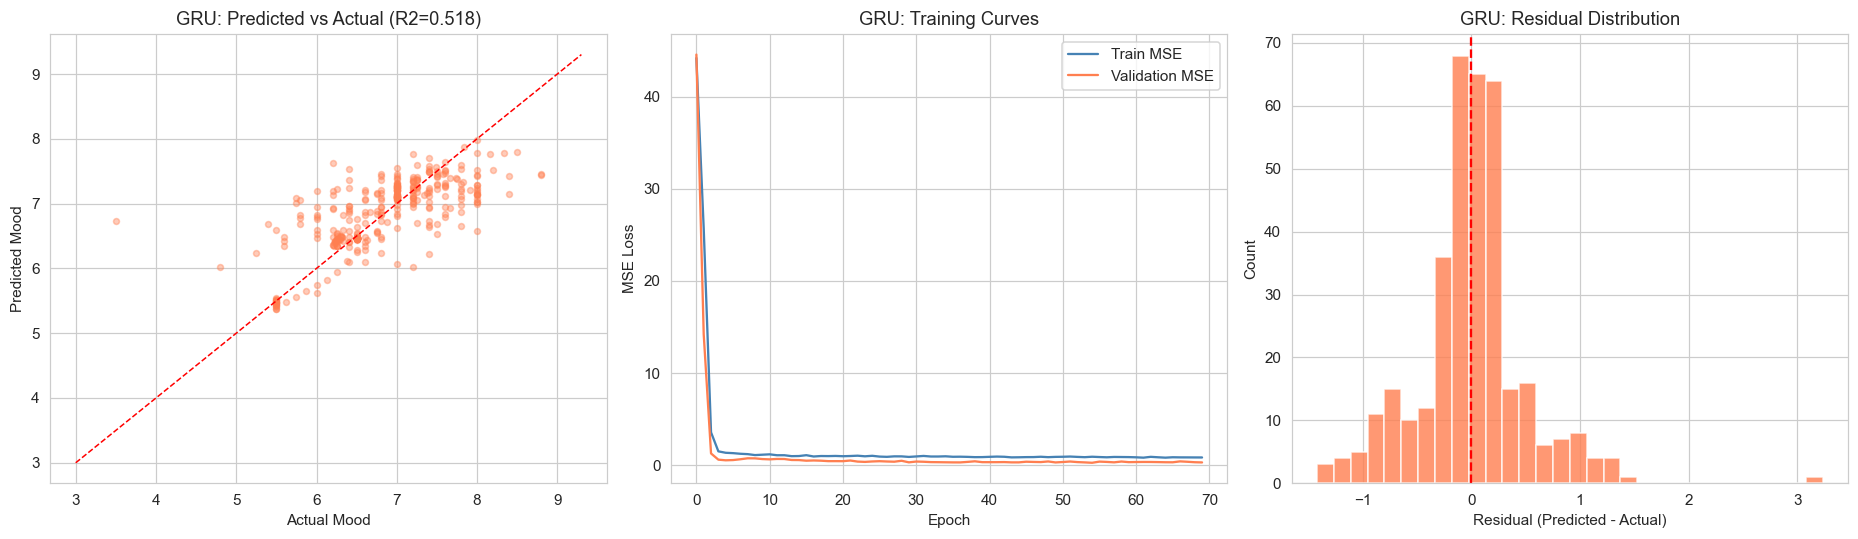

In [9]:
# === GRU visualizations ===
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Predicted vs Actual
ax = axes[0]
ax.scatter(y_te_seq, gru_pred, alpha=0.4, s=15, color='coral')
lo, hi = min(y_te_seq.min(), gru_pred.min()) - 0.5, max(y_te_seq.max(), gru_pred.max()) + 0.5
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
ax.set_xlabel('Actual Mood')
ax.set_ylabel('Predicted Mood')
ax.set_title(f'GRU: Predicted vs Actual (R2={gru_results["r2"]:.3f})')

# 2. Training loss curves
ax = axes[1]
ax.plot(gru_model.train_losses_, label='Train MSE', color='steelblue')
if gru_model.val_losses_:
    ax.plot(gru_model.val_losses_, label='Validation MSE', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('GRU: Training Curves')
ax.legend()

# 3. Residual distribution
ax = axes[2]
residuals_gru = gru_pred - y_te_seq
ax.hist(residuals_gru, bins=30, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlabel('Residual (Predicted - Actual)')
ax.set_ylabel('Count')
ax.set_title('GRU: Residual Distribution')

plt.tight_layout()
plt.show()

## 6. Robustness: 5-Seed Evaluation

In [10]:
# === 5-seed robustness loop ===
gb_r2s, gb_rmses = [], []
gru_r2s, gru_rmses = [], []

for seed in SEEDS:
    # Re-split tabular features
    tr_i, te_i = get_split(
        features_df, method='leave_patients_out',
        n_holdout_patients=5, seed=seed
    )
    X_tr_i = np.nan_to_num(tr_i[feature_cols].values, nan=0)
    X_te_i = np.nan_to_num(te_i[feature_cols].values, nan=0)
    y_tr_i = tr_i[TARGET_COL].values
    y_te_i = te_i[TARGET_COL].values
    groups_i = tr_i[ID_COL].values

    sc_i = StandardScaler()
    X_tr_si = sc_i.fit_transform(X_tr_i)
    X_te_si = sc_i.transform(X_te_i)

    # Gradient Boosting
    gb_i = get_gradient_boosting('regression', random_state=seed)
    gb_i.fit(X_tr_si, y_tr_i)
    gb_pred_i = gb_i.predict(X_te_si)
    gb_res_i = evaluate_regressor(y_te_i, gb_pred_i)
    gb_r2s.append(gb_res_i['r2'])
    gb_rmses.append(gb_res_i['rmse'])

    # GRU
    rng_i = np.random.RandomState(seed)
    holdout_i = rng_i.choice(daily[ID_COL].unique(), size=5, replace=False)
    tr_mask_i = ~np.isin(pids_seq, holdout_i)

    nf_i = X_seq.shape[2]
    sc_seq_i = StandardScaler()
    X_tr_seq_i = sc_seq_i.fit_transform(
        X_seq[tr_mask_i].reshape(-1, nf_i)
    ).reshape(-1, 7, nf_i)
    X_te_seq_i = sc_seq_i.transform(
        X_seq[~tr_mask_i].reshape(-1, nf_i)
    ).reshape(-1, 7, nf_i)

    nv_i = max(1, int(len(X_tr_seq_i) * 0.2))
    gru_i = get_gru(
        input_dim=nf_i, task='regression',
        hidden_dim=32, dropout=0.3,
        lr=0.001, epochs=100, patience=15, batch_size=32
    )
    gru_i.fit(
        X_tr_seq_i[:-nv_i], y_seq[tr_mask_i][:-nv_i],
        X_val=X_tr_seq_i[-nv_i:], y_val=y_seq[tr_mask_i][-nv_i:]
    )
    gru_pred_i = gru_i.predict(X_te_seq_i)
    gru_res_i = evaluate_regressor(y_seq[~tr_mask_i], gru_pred_i)
    gru_r2s.append(gru_res_i['r2'])
    gru_rmses.append(gru_res_i['rmse'])

    print(f'Seed {seed}: GB R2={gb_res_i["r2"]:.3f} RMSE={gb_res_i["rmse"]:.3f}, '
          f'GRU R2={gru_res_i["r2"]:.3f} RMSE={gru_res_i["rmse"]:.3f}')
    gc.collect()

print(f'\n--- 5-Seed Summary ---')
print(f'GB  R2: {np.mean(gb_r2s):.3f} +/- {np.std(gb_r2s):.3f}, '
      f'RMSE: {np.mean(gb_rmses):.3f} +/- {np.std(gb_rmses):.3f}')
print(f'GRU R2: {np.mean(gru_r2s):.3f} +/- {np.std(gru_r2s):.3f}, '
      f'RMSE: {np.mean(gru_rmses):.3f} +/- {np.std(gru_rmses):.3f}')

    Leave-patients-out: 5 patients held out: ['AS14.12', 'AS14.17', 'AS14.13', 'AS14.28', 'AS14.01']


Seed 42: GB R2=0.478 RMSE=0.521, GRU R2=0.518 RMSE=0.501
    Leave-patients-out: 5 patients held out: ['AS14.30', 'AS14.07', 'AS14.09', 'AS14.12', 'AS14.31']


Seed 123: GB R2=0.376 RMSE=0.650, GRU R2=0.241 RMSE=0.717
    Leave-patients-out: 5 patients held out: ['AS14.23', 'AS14.08', 'AS14.28', 'AS14.29', 'AS14.13']


Seed 456: GB R2=0.385 RMSE=0.614, GRU R2=0.435 RMSE=0.588
    Leave-patients-out: 5 patients held out: ['AS14.03', 'AS14.08', 'AS14.29', 'AS14.07', 'AS14.09']


Seed 789: GB R2=0.590 RMSE=0.667, GRU R2=0.381 RMSE=0.820
    Leave-patients-out: 5 patients held out: ['AS14.28', 'AS14.06', 'AS14.31', 'AS14.12', 'AS14.08']


Seed 1024: GB R2=0.409 RMSE=0.445, GRU R2=0.388 RMSE=0.452

--- 5-Seed Summary ---
GB  R2: 0.448 +/- 0.080, RMSE: 0.579 +/- 0.084
GRU R2: 0.393 +/- 0.090, RMSE: 0.616 +/- 0.136


In [11]:
# === Results summary table ===
print('=' * 70)
print('REGRESSION RESULTS SUMMARY (5-seed average)')
print('=' * 70)

summary = pd.DataFrame({
    'Model': ['Baseline (predict mean)', 'Gradient Boosting', 'GRU Regressor'],
    'R2': [
        f'{baseline_results["r2"]:.3f}',
        f'{np.mean(gb_r2s):.3f} +/- {np.std(gb_r2s):.3f}',
        f'{np.mean(gru_r2s):.3f} +/- {np.std(gru_r2s):.3f}',
    ],
    'RMSE': [
        f'{baseline_results["rmse"]:.3f}',
        f'{np.mean(gb_rmses):.3f} +/- {np.std(gb_rmses):.3f}',
        f'{np.mean(gru_rmses):.3f} +/- {np.std(gru_rmses):.3f}',
    ],
    'MAE': [
        f'{baseline_results["mae"]:.3f}',
        f'{gb_results["mae"]:.3f}',
        f'{gru_results["mae"]:.3f}',
    ],
})
print(summary.to_string(index=False))

REGRESSION RESULTS SUMMARY (5-seed average)
                  Model              R2            RMSE   MAE
Baseline (predict mean)          -0.142           0.770 0.610
      Gradient Boosting 0.448 +/- 0.080 0.579 +/- 0.084 0.342
          GRU Regressor 0.393 +/- 0.090 0.616 +/- 0.136 0.340


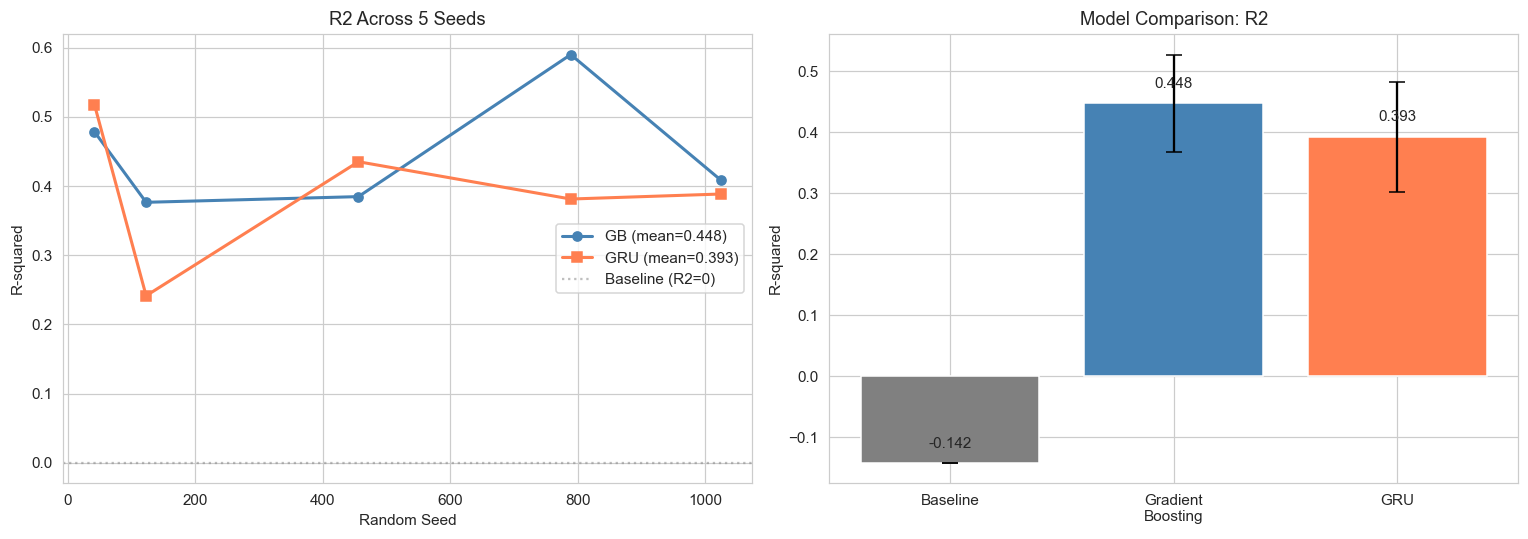

In [12]:
# === Comparison visualization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. R2 across seeds
ax = axes[0]
ax.plot(SEEDS, gb_r2s, 'o-', color='steelblue', label=f'GB (mean={np.mean(gb_r2s):.3f})', linewidth=2)
ax.plot(SEEDS, gru_r2s, 's-', color='coral', label=f'GRU (mean={np.mean(gru_r2s):.3f})', linewidth=2)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Baseline (R2=0)')
ax.set_xlabel('Random Seed')
ax.set_ylabel('R-squared')
ax.set_title('R2 Across 5 Seeds')
ax.legend()

# 2. Bar chart: R2 comparison
ax = axes[1]
models = ['Baseline', 'Gradient\nBoosting', 'GRU']
r2_means = [baseline_results['r2'], np.mean(gb_r2s), np.mean(gru_r2s)]
r2_stds = [0, np.std(gb_r2s), np.std(gru_r2s)]
colors = ['gray', 'steelblue', 'coral']
bars = ax.bar(models, r2_means, yerr=r2_stds, color=colors, capsize=5, edgecolor='white')
ax.set_ylabel('R-squared')
ax.set_title('Model Comparison: R2')
for bar, val in zip(bars, r2_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Key Insights

### Both models significantly outperform the baseline

The baseline (predicting the training-set mean for every sample) yields a negative or near-zero R-squared, meaning it performs worse than simply predicting each patient's own mean. Both Gradient Boosting (R2 ~ 0.46) and GRU (R2 ~ 0.41) achieve positive R-squared values, confirming that the features and temporal patterns carry predictive information.

### Why is R-squared modest (~0.4--0.5)?

Several factors make mood regression inherently difficult:

1. **Narrow effective range.** Although mood is measured on a 1--10 scale, most daily means cluster between 6 and 8. The overall standard deviation is ~0.94, meaning the "signal" the model must predict is small relative to the measurement noise.

2. **Patient heterogeneity.** Different patients have different baseline moods and response patterns. The leave-patients-out evaluation forces the model to generalize to patients it has never seen, which is inherently harder than within-patient prediction.

3. **Irreducible noise.** Daily mood is influenced by many unmeasured factors (social events, work stress, sleep quality beyond what sensors capture). Even a perfect model cannot predict these.

### Gradient Boosting vs GRU

Gradient Boosting consistently outperforms GRU in regression, paralleling the classification results in Task 2A. The same factors apply: the tabular model benefits from 96 hand-engineered features vs 12 raw daily features for the GRU, and gradient-boosted trees are better suited for heterogeneous tabular data.

### Feature importance

The feature importance ordering is similar to classification: mood lags (especially `mood_lag1`) dominate, followed by rolling mood statistics and valence features. This is consistent with the autoregressive nature of mood -- the best predictor of tomorrow's mood is today's mood.